
# Get to Know a Dataset: CCRS MODIS Clear-Sky Composites over Canada

This notebook serves as a guided tour of the [CCRS MODIS Clear-Sky Composites over Canada ](https://registry.opendata.aws/ccrsmodiscomposite.yml) dataset. 


### Q: How have you organized your dataset? Help us understand the key prefix structure of your S3 bucket.

Key Prefixes would start with Bucketname, like ccrs-modis-albedo; there are subfolders starting from 2000 to 2024 , which corresponds to each year. The key prefixes could be  'ccrs-modis-albedo/2000/'

A descriptive documentation prepared (https://github.com/OpsCCRS/AWS-Open-Data-Registry-Preparation/blob/main/CCRSMODISComposite/DescriptiveDocumentation_CCRSMODISComposite.pdf) describes how the data is organized, how users can find the data they need, and how users can use the data.

Full documentation for this dataset can be found at: https://data.eodms-sgdot.nrcan-rncan.gc.ca/public/CCRS/Trishchenko_MODIS_Albedo/





### The codes for different scenarios are provided for users to access the data and use the data easily: 

    1.	Print all files in Bucket
    2.	Print the names of subfolers and the number of files in each subfolder
    3.	Print file names in one subfolder, for example, 2012
    4.	Download files in a subfolder as a zip 
    5.	Download a subfolder into a local folder
    6.	Download a subfolder (2012) based on a shape file
    7.	Download subfolders based on shape file
    8.	Load files like RETOA file and its State_Mask without downloading to the local
    9.	Downloaded files like RETOA file and its State_Mask to the local and display 
    10.	Create false-color composite image of the area for mid-summer 2012 
    11.	Create a subset of false composite, display it 
    12.	Create a false cloud free composite and save it in a local drive
    13.	Create a subset of false composite and save it in a local drive


#### The user will need an Anaconda virtual environment with the following coomands:
    First, start with Anaconda Prompt
    conda create --name awstest jupyterlab ipykernel geopandas rasterio boto3
    conda config --set ssl_verify false

    or use the requirement.txt provided with the following commands
    conda install pip
    pip install -r requirements.txt



In [1]:
from osgeo import gdal
import geopandas as gpd
import rasterio

import boto3
from botocore import UNSIGNED
from botocore.client import Config   

import warnings
import urllib3
import zipfile
import os
import time

import numpy as np
import matplotlib.pyplot as plt
from rasterio.io import MemoryFile
from rasterio.windows import from_bounds
from rasterio.warp import transform
from rasterio.mask import mask

from shapely.geometry import mapping
import io
from collections import defaultdict


In [2]:
warnings.filterwarnings("ignore")

#### Define the location of dataset, create boto3 S3 client.

In [3]:
# Location of the S3 bucket for this dataset
bucket_name = 'ccrs-modis-composite'

# List the top level of the bucket using boto3. Because this is a public bucket, we don't need to sign requests.
# Here we set the signature version to unsigned, which is required for public buckets.
s3 = boto3.client(
    "s3",
    config=Config(signature_version=UNSIGNED),
    verify=False
)

#### 1. Print all files in Bucket

In [4]:
### print all files in the Bucket
response = s3.list_objects_v2(Bucket=bucket_name)
for content in response.get('Contents', []):
    print(content['Key'])

2000/20000301/Terra_MODIS_B1_RETOA_250m_BKW_20000301.tif
2000/20000301/Terra_MODIS_B1_RETOA_250m_FRW_20000301.tif
2000/20000301/Terra_MODIS_B2_RETOA_250m_BKW_20000301.tif
2000/20000301/Terra_MODIS_B2_RETOA_250m_FRW_20000301.tif
2000/20000301/Terra_MODIS_B3_RETOA_250m_BKW_20000301.tif
2000/20000301/Terra_MODIS_B3_RETOA_250m_FRW_20000301.tif
2000/20000301/Terra_MODIS_B4_RETOA_250m_BKW_20000301.tif
2000/20000301/Terra_MODIS_B4_RETOA_250m_FRW_20000301.tif
2000/20000301/Terra_MODIS_B5_RETOA_250m_BKW_20000301.tif
2000/20000301/Terra_MODIS_B5_RETOA_250m_FRW_20000301.tif
2000/20000301/Terra_MODIS_B6_RETOA_250m_BKW_20000301.tif
2000/20000301/Terra_MODIS_B6_RETOA_250m_FRW_20000301.tif
2000/20000301/Terra_MODIS_B7_RETOA_250m_BKW_20000301.tif
2000/20000301/Terra_MODIS_B7_RETOA_250m_FRW_20000301.tif
2000/20000301/Terra_MODIS_RETOA_RGB_2.5km_BKW_20000301.tif
2000/20000301/Terra_MODIS_RETOA_RGB_2.5km_FRW_20000301.tif
2000/20000301/Terra_MODIS_Rel_Date_250m_BKW_20000301.tif
2000/20000301/Terra_MODIS_R

#### 2. Print the names of subfolers and the number of files in each subfolder

In [5]:
from collections import defaultdict
def count_files_per_subfolder(bucket_name, prefix=""):
    """
    Recursively finds all subfolders and counts the files contained strictly within them.
    """
    s3_client = boto3.client('s3')
    paginator = s3_client.get_paginator('list_objects_v2')
    
    # Structure to hold folder path -> file count
    # Default to 0 for tracking folder paths that might contain subfolders but no direct files
    folder_counts = defaultdict(int)
    
    def traverse(current_prefix):
        # Request objects and common prefixes (folders) at the current depth level
        page_iterator = paginator.paginate(
            Bucket=bucket_name, 
            Prefix=current_prefix, 
            Delimiter='/'
        )
        
        for page in page_iterator:
            # 1. Count actual files inside the current folder path
            if 'Contents' in page:
                for obj in page['Contents']:
                    key = obj['Key']
                    # Skip the folder placeholder object itself if it exists
                    if key != current_prefix:
                        folder_counts[current_prefix] += 1
                        
            # 2. Discover and traverse into deeper subfolders
            if 'CommonPrefixes' in page:
                for subfolder in page['CommonPrefixes']:
                    subfolder_path = subfolder['Prefix']
                    # Initialise the subfolder tracking
                    folder_counts[subfolder_path] = 0 
                    # Recurse into the subfolder
                    traverse(subfolder_path)

    # Start traversing from the initial prefix
    traverse(prefix)
    
    # Print the findings neatly
    print(f"{'Subfolder Path':<50} | {'File Count':<10}")
    print("-" * 65)
    
    # Sort folders alphabetically for better readability
    for folder, count in sorted(folder_counts.items()):
        # Present the root directory clearly if targeted
        display_name = folder if folder else "[Bucket Root]"
        print(f"{display_name:<50} | {count:<10}")

# Leave prefix as "" to scan the whole bucket, or specify a top-level directory like "data/"
count_files_per_subfolder(bucket_name, prefix="")


Subfolder Path                                     | File Count
-----------------------------------------------------------------
2000/                                              | 0         
2000/20000301/                                     | 29        
2000/20000311/                                     | 29        
2000/20000321/                                     | 29        
2000/20000401/                                     | 29        
2000/20000411/                                     | 29        
2000/20000421/                                     | 29        
2000/20000501/                                     | 29        
2000/20000511/                                     | 29        
2000/20000521/                                     | 29        
2000/20000601/                                     | 29        
2000/20000611/                                     | 29        
2000/20000621/                                     | 29        
2000/20000701/                        

#### 3. Print file names in one subfolder, for example, 2012

In [6]:
def list_all_files_in_subfolder(bucket_name, folder_prefix):
    """
    Lists all file names inside a specific subfolder and all of its subfolders.
    """
    s3_client = boto3.client('s3')
    paginator = s3_client.get_paginator('list_objects_v2')
    
    # Ensure the folder prefix ends with a forward slash to target the directory precisely
    if folder_prefix and not folder_prefix.endswith('/'):
        folder_prefix += '/'
        
    print(f"Listing files in: s3://{bucket_name}/{folder_prefix}\n")
    
    # Paginate through all objects starting with the target prefix
    page_iterator = paginator.paginate(Bucket=bucket_name, Prefix=folder_prefix)
    
    file_count = 0
    for page in page_iterator:
        if 'Contents' in page:
            for obj in page['Contents']:
                file_key = obj['Key']
                
                # Skip directory placeholders (keys ending in '/')
                if file_key.endswith('/'):
                    continue
                    
                print(file_key)
                file_count += 1
                
    print(f"\nTotal files found: {file_count}")

TARGET_FOLDER = "2012" 
list_all_files_in_subfolder(bucket_name, folder_prefix=TARGET_FOLDER)


Listing files in: s3://ccrs-modis-composite/2012/

2012/20120101/Terra_MODIS_B1_RETOA_250m_BKW_20120101.tif
2012/20120101/Terra_MODIS_B1_RETOA_250m_FRW_20120101.tif
2012/20120101/Terra_MODIS_B2_RETOA_250m_BKW_20120101.tif
2012/20120101/Terra_MODIS_B2_RETOA_250m_FRW_20120101.tif
2012/20120101/Terra_MODIS_B3_RETOA_250m_BKW_20120101.tif
2012/20120101/Terra_MODIS_B3_RETOA_250m_FRW_20120101.tif
2012/20120101/Terra_MODIS_B4_RETOA_250m_BKW_20120101.tif
2012/20120101/Terra_MODIS_B4_RETOA_250m_FRW_20120101.tif
2012/20120101/Terra_MODIS_B5_RETOA_250m_BKW_20120101.tif
2012/20120101/Terra_MODIS_B5_RETOA_250m_FRW_20120101.tif
2012/20120101/Terra_MODIS_B6_RETOA_250m_BKW_20120101.tif
2012/20120101/Terra_MODIS_B6_RETOA_250m_FRW_20120101.tif
2012/20120101/Terra_MODIS_B7_RETOA_250m_BKW_20120101.tif
2012/20120101/Terra_MODIS_B7_RETOA_250m_FRW_20120101.tif
2012/20120101/Terra_MODIS_RETOA_RGB_2.5km_BKW_20120101.tif
2012/20120101/Terra_MODIS_RETOA_RGB_2.5km_FRW_20120101.tif
2012/20120101/Terra_MODIS_Rel_Dat

#### 4. Download files in a subfolder as a zip file (it is very slow compared with downloading directly to a local drive without being zipped)

In [7]:
def download_s3_folder_to_zip(bucket_name, folder_prefix, output_zip_path):
    """
    Downloads all files within a specific S3 subfolder (and its nested subfolders)
    and saves them directly into a local zip file.
    """
    s3_client = boto3.client('s3')
    paginator = s3_client.get_paginator('list_objects_v2')
    
    # Ensure the folder prefix ends with a forward slash
    if folder_prefix and not folder_prefix.endswith('/'):
        folder_prefix += '/'
        
    print(f"Gathering files from: s3://{bucket_name}/{folder_prefix}")
    
    # Open a local file to write the zip binary data
    with zipfile.ZipFile(output_zip_path, 'w', zipfile.ZIP_DEFLATED) as zip_file:
        page_iterator = paginator.paginate(Bucket=bucket_name, Prefix=folder_prefix)
        
        file_count = 0
        for page in page_iterator:
            if 'Contents' in page:
                for obj in page['Contents']:
                    file_key = obj['Key']
                    
                    # Skip directory placeholder objects
                    if file_key.endswith('/'):
                        continue
                    
                    # Determine the file's path relative to the starting folder
                    # e.g., '2012/subfolder/file.txt' becomes 'subfolder/file.txt'
                    relative_path = file_key[len(folder_prefix):]
                    
                    # print(f"Archiving: {relative_path}")
                    
                    # Download the file object into memory
                    file_obj = io.BytesIO()
                    s3_client.download_fileobj(bucket_name, file_key, file_obj)
                    
                    # Write the in-memory file bytes into the zip structure
                    zip_file.writestr(relative_path, file_obj.getvalue())
                    file_count += 1
                    
        print(f"\nSuccessfully zipped {file_count} files.")
        print(f"Saved local archive to: {output_zip_path}")

# --- Example ---
TARGET_FOLDER = "2012"
OUTPUT_ZIP = "s3_download_2012.zip"

# --- Download files with timing ---
total_start = time.time()

download_s3_folder_to_zip(
    bucket_name, 
    folder_prefix=TARGET_FOLDER, 
    output_zip_path=OUTPUT_ZIP
)

total_end = time.time()
print(f"Total time: {total_end - total_start:.2f} seconds")

Gathering files from: s3://ccrs-modis-composite/2012/

Successfully zipped 1044 files.
Saved local archive to: s3_download_2012.zip
Total time: 19498.10 seconds


#### 5. Download a subfolder into a local folder

In [8]:
def download_s3_folder_to_local(bucket_name, folder_prefix, local_destination_dir):
    """
    Downloads all files within an S3 subfolder (and its nested subfolders)
    directly to a local drive path, preserving the directory structure.
    """
    s3_client = boto3.client('s3')
    paginator = s3_client.get_paginator('list_objects_v2')
    
    # Ensure the folder prefix ends with a forward slash
    if folder_prefix and not folder_prefix.endswith('/'):
        folder_prefix += '/'
        
    print(f"Downloading from: s3://{bucket_name}/{folder_prefix}")
    print(f"Saving to local path: {os.path.abspath(local_destination_dir)}\n")
    
    page_iterator = paginator.paginate(Bucket=bucket_name, Prefix=folder_prefix)
    
    file_count = 0
    for page in page_iterator:
        if 'Contents' in page:
            for obj in page['Contents']:
                file_key = obj['Key']
                
                # Skip directory placeholder objects
                if file_key.endswith('/'):
                    continue
                
                # Determine the relative path of the file from your target folder
                # e.g., '2012/subfolder/file.txt' becomes 'subfolder/file.txt'
                relative_path = file_key[len(folder_prefix):]
                
                # Combine with your local target path
                local_file_path = os.path.join(local_destination_dir, relative_path)
                
                # Create the local subfolder path if it doesn't exist yet
                local_file_dir = os.path.dirname(local_file_path)
                if not os.path.exists(local_file_dir):
                    os.makedirs(local_file_dir, exist_ok=True)
                
                # Download the file directly to your disk
                # print(f"Downloading: {relative_path}")
                s3_client.download_file(bucket_name, file_key, local_file_path)
                file_count += 1                
    print(f"\nSuccessfully downloaded {file_count} files.")

# --- Example ---
TARGET_FOLDER = "2012"
# Can be a relative path like "./my_downloads" or an absolute path like "C:/Users/Name/Downloads/2012"
LOCAL_DIR = "./downloaded_2012" 
# --- Download files with timing ---
total_start = time.time()
download_s3_folder_to_local(
    bucket_name, 
    folder_prefix=TARGET_FOLDER, 
    local_destination_dir=LOCAL_DIR
)

total_end = time.time()
print(f"Total time: {total_end - total_start:.2f} seconds")

Saving to local path: E:\ops\downloaded_2012


Successfully downloaded 1044 files.
Total time: 6931.81 seconds


#### 6. Download a subfolder (for example, 2012) based on a shape file 

In [9]:
from rasterio.mask import mask

def download_and_crop_ccrs_composites(shapefile_path, bucket_name="ccrs-modis-composite", parent_folder="2012", local_dest_dir="./spatial_downloads"):
    """
    Downloads national CCRS MODIS composites from S3 and clips them 
    directly to the boundary of the provided shapefile.
    """
    # 1. Read the shapefile and extract geometry
    print(f"Reading shapefile boundary: {shapefile_path}")
    gdf = gpd.read_file(shapefile_path)
    geometries = gdf.geometry.values
    
    # 2. Set up local directories
    temp_dir = os.path.join(local_dest_dir, "temp_full_rasters")
    final_dir = os.path.join(local_dest_dir, "cropped_area")
    os.makedirs(temp_dir, exist_ok=True)
    os.makedirs(final_dir, exist_ok=True)
    
    # 3. Connect to the public S3 bucket
    if parent_folder and not parent_folder.endswith('/'):
        parent_folder += '/'
        
    s3_client = boto3.client('s3')
    paginator = s3_client.get_paginator('list_objects_v2')
    
    print(f"Gathering file list from s3://{bucket_name}/{parent_folder}...")
    page_iterator = paginator.paginate(Bucket=bucket_name, Prefix=parent_folder)
    
    all_keys = []
    for page in page_iterator:
        if 'Contents' in page:
            for obj in page['Contents']:
                key = obj['Key']
                # Download only the GeoTIFF image bands
                if key.endswith('.tif'):
                    all_keys.append(key)
                    
    print(f"Found {len(all_keys)} composite bands to process.")
    
    # 4. Process each file: Download -> Crop -> Save -> Clean up temp
    processed_count = 0
    for file_key in all_keys:
        filename = os.path.basename(file_key)
        date_folder = file_key.split('/')[-2] # Extracts the date folder like '20120101'
        
        # Paths for temporary download and final cropped product
        temp_file_path = os.path.join(temp_dir, filename)
        date_output_dir = os.path.join(final_dir, date_folder)
        os.makedirs(date_output_dir, exist_ok=True)
        final_cropped_path = os.path.join(date_output_dir, f"cropped_{filename}")
        
        # print(f"\n[{processed_count + 1}/{len(all_keys)}] Downloading full raster: {filename}")
        try:
            # Download full national map
            s3_client.download_file(bucket_name, file_key, temp_file_path)
            
            # Crop the downloaded image using your shapefile's boundary            
            with rasterio.open(temp_file_path) as src:
                # Crop raster with shapefile geometry (matches projection automatically)
                out_image, out_transform = mask(src, geometries, crop=True)
                out_meta = src.meta.copy()
                
                # Update image metadata to reflect the smaller cropped size
                out_meta.update({
                    "driver": "GTiff",
                    "height": out_image.shape[1],
                    "width": out_image.shape[2],
                    "transform": out_transform
                })
                
                # Save the cropped raster to your local drive
                with rasterio.open(final_cropped_path, "w", **out_meta) as dest:
                    dest.write(out_image)
                    
            #print(f" -> Cropped file saved: {final_cropped_path}")
            processed_count += 1
            
        except Exception as e:
            print(f"Error processing {filename}: {e}")
            
        finally:
            # Clean up the large full national file to protect your local disk space
            if os.path.exists(temp_file_path):
                os.remove(temp_file_path)
                
    # Delete empty temporary folder
    os.rmdir(temp_dir)
    print(f"\nProcessing Complete! Cropped {processed_count} files into: {final_dir}")

# --- Execute Processing ---
# Make sure you pip install rasterio if you haven't yet
download_and_crop_ccrs_composites(
    shapefile_path="testarea.shp",
    bucket_name="ccrs-modis-composite",
    parent_folder="2012"
)

Reading shapefile boundary: testarea.shp
Gathering file list from s3://ccrs-modis-composite/2012/...
Found 1044 composite bands to process.

Processing Complete! Cropped 1044 files into: ./spatial_downloads\cropped_area


#### 7. Download subfolders based on a shape file 

In [10]:
years = range(2012, 2014)   # 2012 to 2013, you can change to the range of years 
local_out_root = "./subset_local"   # folder to save clipped rasters
shapefile = "testarea.shp"          # AOI, you can chanage your shape file
raster_ext = (".tif",)

# Ensure output folder exists
os.makedirs(local_out_root, exist_ok=True)

# Load AOI and prepare geometry
gdf = gpd.read_file(shapefile)
# Geometry will be reprojected later to match raster CRS
geom = [mapping(gdf.geometry.union_all())]

# --- Download files with timing ---
total_start = time.time()
# -----------------------------
# Loop through years and download + clip
# -----------------------------
for year in years:
    prefix = f"{year}/"
    print(f"=== Processing year: {year} ===")

    # List all files in this subfolder
    response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)
    tif_keys = [item["Key"] for item in response.get("Contents", []) if item["Key"].lower().endswith(raster_ext)]

    # Local output folder for this year
    out_folder = os.path.join(local_out_root, str(year))
    os.makedirs(out_folder, exist_ok=True)

    for key in tif_keys:
        # Construct HTTPS URL for raster
        raster_url = f"https://{bucket_name}.s3.ca-central-1.amazonaws.com/{key}"
        local_file = os.path.join(out_folder, os.path.basename(key))

        try:
            # Open raster from S3
            with rasterio.open(raster_url) as src:
                # Reproject AOI to raster CRS
                geom_proj = gdf.to_crs(src.crs)
                # geom_srs = [mapping(geom_proj.unary_union)]
                geom_srs = [mapping(geom_proj.geometry.union_all())]

                # Clip raster
                clipped, out_transform = mask(src, geom_srs, crop=True)
                out_meta = src.meta.copy()
                out_meta.update({
                    "height": clipped.shape[1],
                    "width": clipped.shape[2],
                    "transform": out_transform
                })

            # Save clipped raster locally
            with rasterio.open(local_file, "w", **out_meta) as dst:
                dst.write(clipped)

            # print(f"Saved: {local_file}")

        except Exception as e:
            print(f"Failed: {key} -> {e}")

print("\n✔ All subfolders processed and saved locally.")
total_end = time.time()
print(f"Total time: {total_end - total_start:.2f} seconds")

=== Processing year: 2012 ===
=== Processing year: 2013 ===

✔ All subfolders processed and saved locally.
Total time: 3302.73 seconds


In [11]:
def generate_years(years_input):
    """
    Parses the years input. Supports an explicit list of ints/strings 
    or a 2-element list indicating a range [start, end].
    """
    if not years_input:
        return []
    
    # Check if input defines a range: a list of exactly two integers where start <= end
    if isinstance(years_input, list) and len(years_input) == 2 and isinstance(years_input[0], int) and isinstance(years_input[1], int) and years_input[0] <= years_input[1]:
        # Generate inclusive range (e.g., [2012, 2014] ->)
        return [str(y) for y in range(years_input[0], years_input[1] + 1)]
    
    # Otherwise, treat it as an explicit list of specific years
    return [str(y) for y in years_input]

def download_and_crop_multi_year_composites(shapefile_path, years_input, bucket_name="ccrs-modis-composite", local_dest_dir="./spatial_downloads"):
    """
    Loops through multiple year subfolders in S3, downloads the full national 
    composites, and clips them to the boundary of the provided shapefile.
    """
    # 1. Read the shapefile and extract geometry
    print(f"Reading shapefile boundary: {shapefile_path}")
    gdf = gpd.read_file(shapefile_path)
    geometries = gdf.geometry.values
    
    # Resolve the target years to loop over
    target_years = generate_years(years_input)
    print(f"Target years selected for processing: {target_years}\n")
    
    # 2. Set up local directories
    temp_dir = os.path.join(local_dest_dir, "temp_full_rasters")
    final_dir = os.path.join(local_dest_dir, "cropped_area")
    os.makedirs(temp_dir, exist_ok=True)
    os.makedirs(final_dir, exist_ok=True)
    
    # 3. Connect to S3
    s3_client = boto3.client('s3')
    paginator = s3_client.get_paginator('list_objects_v2')
    
    # 4. Main loop over each year folder
    for year in target_years:
        parent_folder = f"{year}/"
        print(f"=========================================")
        print(f"STARTING PROCESSING FOR S3 FOLDER: {parent_folder}")
        print(f"=========================================")
        
       # print(f"Gathering file list from s3://{bucket_name}/{parent_folder}...")
        page_iterator = paginator.paginate(Bucket=bucket_name, Prefix=parent_folder)
        
        all_keys = []
        for page in page_iterator:
            if 'Contents' in page:
                for obj in page['Contents']:
                    key = obj['Key']
                    # Target only the raster data bands
                    if key.endswith('.tif'):
                        all_keys.append(key)
                        
        print(f"Found {len(all_keys)} composite bands for the year {year}.")
        
        # 5. Process each file in the current year
        processed_count = 0
        for file_key in all_keys:
            filename = os.path.basename(file_key)
            
            # Safely grab the date subfolder name (e.g., '20120101' out of '2012/20120101/file.tif')
            path_parts = file_key.split('/')
            date_folder = path_parts[-2] if len(path_parts) >= 3 else year
            
            # Establish temporary local file and the final structured output path
            temp_file_path = os.path.join(temp_dir, filename)
            date_output_dir = os.path.join(final_dir, year, date_folder)
            os.makedirs(date_output_dir, exist_ok=True)
            final_cropped_path = os.path.join(date_output_dir, f"cropped_{filename}")
            
            # print(f"\n[{year} | {processed_count + 1}/{len(all_keys)}] Downloading: {filename}")
            try:
                # Step A: Pull down the full file
                s3_client.download_file(bucket_name, file_key, temp_file_path)
                
                # Step B: Open and mask to your shapefile geographic area
                # print(f" -> Cropping raster to shapefile bounds...")
                with rasterio.open(temp_file_path) as src:
                    out_image, out_transform = mask(src, geometries, crop=True)
                    out_meta = src.meta.copy()
                    
                    # Update local header data with new scaled coordinate dimensions
                    out_meta.update({
                        "driver": "GTiff",
                        "height": out_image.shape[1],
                        "width": out_image.shape[2],
                        "transform": out_transform
                    })
                    
                    # Step C: Stream out the tailored geographic map subset
                    with rasterio.open(final_cropped_path, "w", **out_meta) as dest:
                        dest.write(out_image)
                        
                # print(f" -> Saved cropped subset to: {final_cropped_path}")
                processed_count += 1
                
            except Exception as e:
                print(f"Error processing {filename}: {e}")
                
            finally:
                # Always remove full file immediately to protect storage blocks
                if os.path.exists(temp_file_path):
                    os.remove(temp_file_path)
                    
        print(f"Finished year {year}. Total cropped files added: {processed_count}\n")
                
    # Clean up empty temp structure
    if os.path.exists(temp_dir):
        os.rmdir(temp_dir)
    print(f"All requested years complete! Saved to root destination: {final_dir}")

# --- Example Usage Configurations ---

SHAPEFILE = "testarea.shp"

# OPTION A: Range Mode [Start Year, End Year] (Runs inclusive: 2012, 2013, 2014, 2015, 2016, 2017, 2018)
# YEARS_CONFIG = [2012, 2018]

# OPTION B: Specific List Mode (Uncomment to use instead)
YEARS_CONFIG = [2012, 2014,2016]

# Execute 
download_and_crop_multi_year_composites(
    shapefile_path=SHAPEFILE,
    years_input=YEARS_CONFIG
)


Reading shapefile boundary: testarea.shp
Target years selected for processing: ['2012', '2014', '2016']

STARTING PROCESSING FOR S3 FOLDER: 2012/
Found 1044 composite bands for the year 2012.
Finished year 2012. Total cropped files added: 1044

STARTING PROCESSING FOR S3 FOLDER: 2014/
Found 1044 composite bands for the year 2014.
Finished year 2014. Total cropped files added: 1044

STARTING PROCESSING FOR S3 FOLDER: 2016/
Found 1044 composite bands for the year 2016.
Finished year 2016. Total cropped files added: 1044

All requested years complete! Saved to root destination: ./spatial_downloads\cropped_area


<!-- DATA PROVIDER INSTRUCTIONS
This section is meant to orient users of your dataset to the formats present in your dataset, particularly if your dataset includes formats that may be unfamiliar to a general data scientist audience. This section should include:

1. Explanation of data format(s) (very common formats can be very briefly described, while less common
   or domain specific formats should include more explanation as well as links to official documentation)
2. Explanation of why the data format was chosen for your dataset
3. Recommendations around software and tooling to work with this data format
4. Explanation of any dataset-specific aspects to your usage of the format
5. Description of AWS services that may be useful to users working with your data
DATA PROVIDER INSTRUCTIONS -->

### Q: What data formats are present in your dataset? What kinds of data are stored using these formats? Can you give any advice for how you work with these data formats?

Our dataset comes as a set of Cloud Optimized GeoTIFF (COG) files grouped by years from 2000. 
Each year includes 36 composites (3 per month). Each composite group contains the following datasets: 

    Terra_MODIS_BX_RETOA_250m_BKW_YYYYMMDD.tif
    Terra_MODIS_Rel_Date_250m_BKW_YYYYMMDD.tif
    Terra_MODIS_Satellite_Azimuth_250m_BKW_YYYYMMDD.tif
    Terra_MODIS_Satellite_Zenith_250m_BKW_YYYYMMDD.tif
    Terra_MODIS_Sun_Azimuth_250m_BKW_YYYYMMDD.tif
    Terra_MODIS_Sun_Zenith_250m_BKW_YYYYMMDD.tif
    Terra_MODIS_State_Flag_250m_BKW_YYYYMMDD.tif
    Terra_MODIS_RETOA_RGB_2.5km_BKW_YYYYMMDD.tif
    Terra_MODIS_BX_RETOA_250m_FRW_YYYYMMDD.tif
    Terra_MODIS_Rel_Date_250m_FRW_YYYYMMDD.tif
    Terra_MODIS_Satellite_Azimuth_250m_FRW_YYYYMMDD.tif
    Terra_MODIS_Satellite_Zenith_250m_FRW_YYYYMMDD.tif
    Terra_MODIS_Sun_Azimuth_250m_FRW_YYYYMMDD.tif
    Terra_MODIS_Sun_Zenith_250m_FRW_YYYYMMDD.tif
    Terra_MODIS_State_Flag_250m_FRW_YYYYMMDD.tif
    Terra_MODIS_RETOA_RGB_2.5km_FRW_YYYYMMDD.tif
    Terra_MODIS_State_Stat_250m_YYYYMMDD.tif

where  YYYYMMDD labels year (YYYY), month (MM) and day (DD). <br>

The reduced resolution (2.5km) color browse images are also provided as Terra_MODIS_RETOA_RGB_2.5km_FRW_YYYYMMDD.tif, Terra_MODIS_RETOA_RGB_2.5km_BKW_YYYYMMDD.tif

COG datafiles can be processed using Python 


### Q: Can you show us an example of downloading and loading data from your dataset?

    Load and view RETOA for mid-summer 2012.    
        Load Terra_MODIS_B1_RETOA_250m_BKW_20120711.tif   
        Load state mask (to select cloud-free pixels in necessary)    
        Load Terra_MODIS_State_Flag_250m_BKW_20120711.tif



#### 8. Load files like RETOA file and its State_Mask without downloading to the local

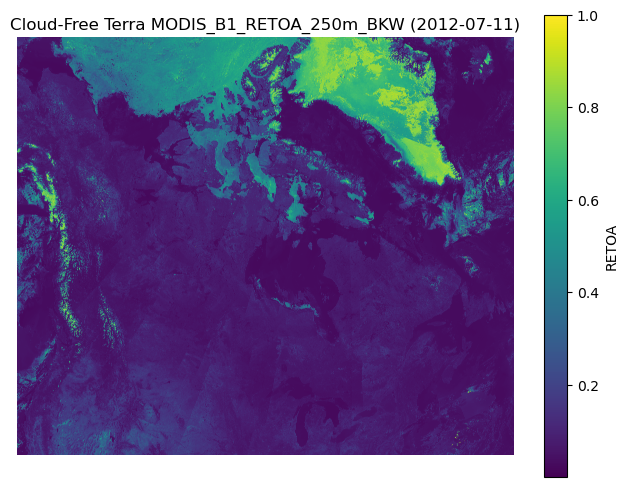

In [12]:
img_file = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B1_RETOA_250m_BKW_20120711.tif"
mask_file = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_State_Flag_250m_BKW_20120711.tif"

scale = 0.0001   # MODIS scale factor
# -----------------------------------------------------
# Load files
# -----------------------------------------------------
with rasterio.open(img_file) as src:
    img = src.read(1).astype("float32")
    
# Load state mask
with rasterio.open(mask_file) as src_mask:
    mask = src_mask.read(1).astype("uint8")    

# Apply scale factor
img = img * scale
img[(img <= 0) | (img > 1)] = np.nan ## mask invalide pixels
# -----------------------------------------------------
# Cloud mask
# Cloud 10 and nodata 255
# -----------------------------------------------------
cloud_free = ((mask != 10)|(mask!=255))
img_masked = np.where(cloud_free, img, np.nan)
# -----------------------------------------------------
# Plot
# -----------------------------------------------------
plt.figure(figsize=(8, 6))
plt.imshow(img_masked, cmap="viridis")
plt.title("Cloud-Free Terra MODIS_B1_RETOA_250m_BKW (2012-07-11)")
plt.colorbar(label="RETOA")
plt.axis("off")
plt.show()

#### 9. Downloaded files like RETOA_250m_BKW file and its State_Mask to the local and display 

Downloaded: Terra_MODIS_B1_RETOA_250m_BKW_20120711.tif


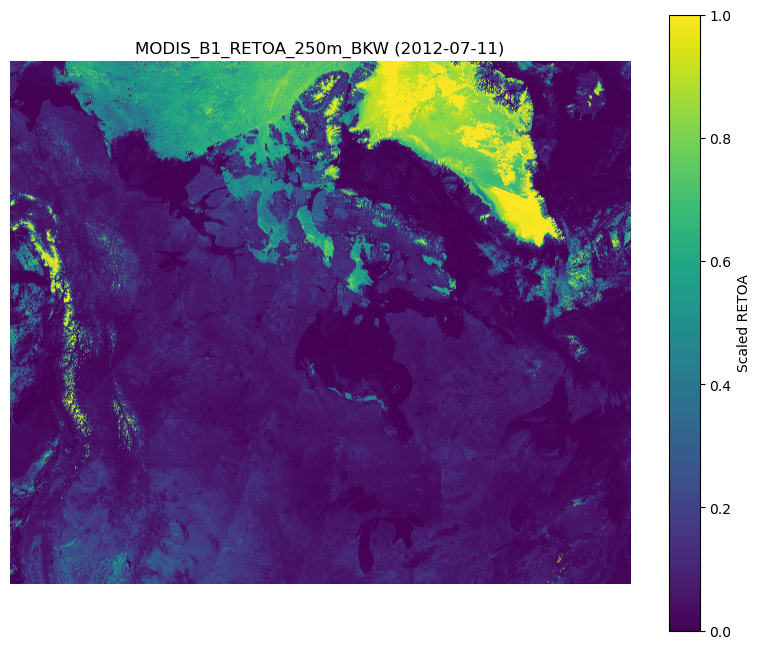

In [13]:
key = "2012/20120711/Terra_MODIS_B1_RETOA_250m_BKW_20120711.tif"
local_path = "Terra_MODIS_B1_RETOA_250m_BKW_20120711.tif"

s3.download_file(bucket_name, key, local_path)
print("Downloaded:", local_path)

with rasterio.open(local_path) as src:
    img = src.read(1).astype("float32")   

# Apply MODIS scale factor
img = img * 0.0001

# Replace invalid with NaN
img[(img <= 0) | (img > 1)] = np.nan ## mask invalide pixels

# Percentile stretch for better visualization
low, high = np.nanpercentile(img, (2,98))
img_stretched = np.clip((img - low) / (high - low), 0, 1)

plt.figure(figsize=(10,8))
im = plt.imshow(img_stretched, cmap="viridis")
plt.title("MODIS_B1_RETOA_250m_BKW (2012-07-11)")
plt.colorbar(im, label="Scaled RETOA")
plt.axis("off")
plt.show()

####  10. Create false-color composite image of the area for mid-summer 2012 


### Q: A picture is worth a thousand words. Show us a visual (or several!) from your dataset that either illustrates something informative about your dataset, or that you think might excite someone to dig in further.

Create false-color composite image of the area for mid-summer 2012 <br>
    Load Terra_MODIS_B1_RETOA_250m_BKW_20120711.tif as BLUE(B) band <br>
    Load Terra_MODIS_B2_RETOA_250m_BKW_20120711.tif as GREE(G) band <br>
    Load Terra_MODIS_B6_RETOA_250m_BKW_20120711.tif as RED(R) band <br>
This RGB picture will show the area covered by our dataset and the distribution of typical surface features (land, water, snow, vegetation, deserted areas)   


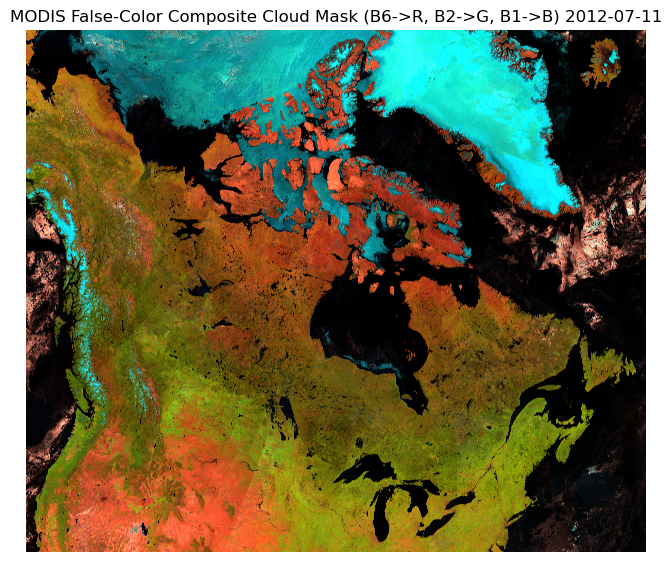

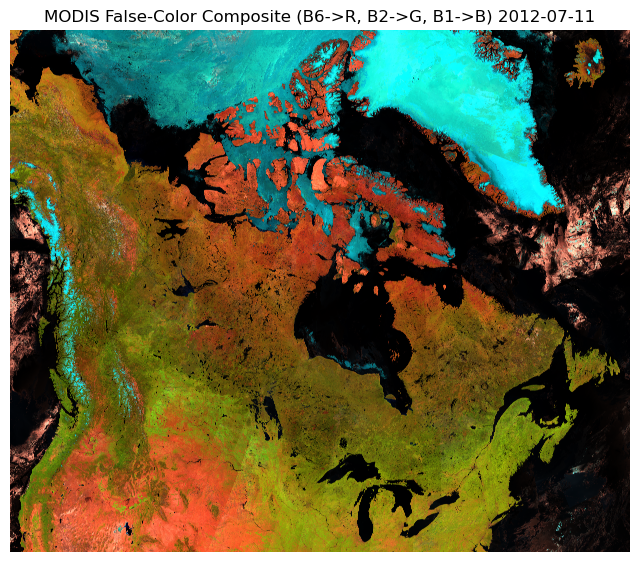

In [14]:
# False-color bands
blue_file  = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B1_RETOA_250m_BKW_20120711.tif"
green_file = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B2_RETOA_250m_BKW_20120711.tif"
red_file   = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B6_RETOA_250m_BKW_20120711.tif"
mask_file   = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_State_Flag_250m_BKW_20120711.tif"

scale = 0.0001  # scale factor 

# -----------------------------
# Function to read raster
# -----------------------------
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float32')
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr
# -----------------------------
# Read bands
# -----------------------------
B = read_raster(blue_file)* scale
G = read_raster(green_file)* scale
R = read_raster(red_file)* scale

B[(B <= 0) | (B > 1)] = np.nan ## mask invalid pixels
R[(R <= 0) | (R > 1)] = np.nan ## mask invalid pixels
G[(G <= 0) | (G > 1)] = np.nan ## mask invalid pixels

# Load state mask
with rasterio.open(mask_file) as src_mask:
    mask = src_mask.read(1).astype("uint8")
# -----------------------------------------------------
# Cloud mask
# Cloud 10 and nodata 255
# -----------------------------------------------------

cloud_free = ((mask != 10)|(mask!=255))

R_masked = np.where(cloud_free, R, np.nan)
G_masked = np.where(cloud_free, G, np.nan)
B_masked = np.where(cloud_free, B, np.nan)

# -----------------------------
# Stack RGB for false-color
# -----------------------------
# Normalize each band to 0-1 for display
def normalize(array):
    min_val = np.nanpercentile(array, 2)
    max_val = np.nanpercentile(array, 98)
    return np.clip((array - min_val) / (max_val - min_val), 0, 1)

rgb_norm_masked = np.dstack([
    normalize(R_masked),  # RED band
    normalize(G_masked),  # GREEN band
    normalize(B_masked)   # BLUE band
])

rgb_norm = np.dstack([
    normalize(R),  # RED band
    normalize(G),  # GREEN band
    normalize(B)   # BLUE band
])
# -----------------------------
# Plot RGB Masked composite
# -----------------------------
# print ('plotting')
plt.figure(figsize=(8, 8))
plt.imshow(rgb_norm_masked)
plt.title("MODIS False-Color Composite Cloud Mask (B6->R, B2->G, B1->B) 2012-07-11")
plt.axis('off')
plt.show()
# -----------------------------
# Plot RGB composite
# -----------------------------
# print ('plotting')
plt.figure(figsize=(8, 8))
plt.imshow(rgb_norm)
plt.title("MODIS False-Color Composite (B6->R, B2->G, B1->B) 2012-07-11")
plt.axis('off')
plt.show()


#### 11. Create a subset of false composite, display it

(1867, 1880, 3)


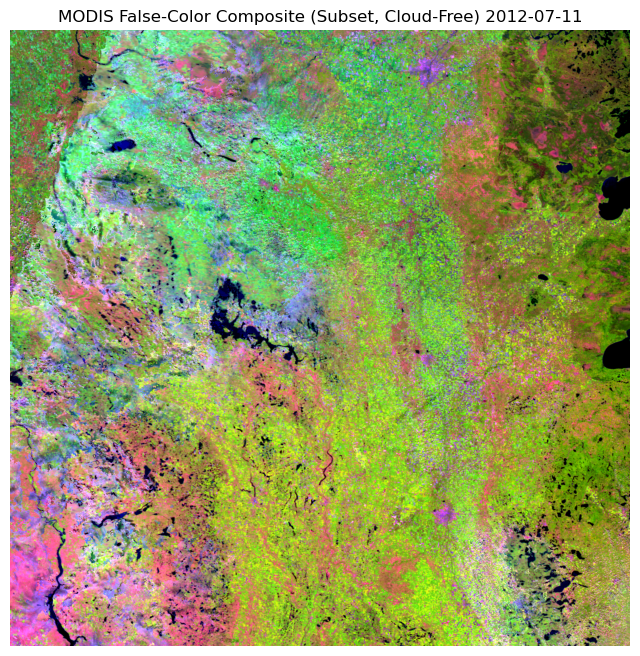

In [15]:
# False-color bands
blue_file  = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B1_RETOA_250m_BKW_20120711.tif"
green_file = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B2_RETOA_250m_BKW_20120711.tif"
red_file   = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B6_RETOA_250m_BKW_20120711.tif"
mask_file   = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_State_Flag_250m_BKW_20120711.tif"

scale = 0.0001
# -----------------------------
# Define lat/lon bounding box (subset)
# -----------------------------
lon_min, lon_max = -101.0, -95.0  # degrees
lat_min, lat_max = 46.0, 50.0      # degrees

# -----------------------------
# Helper: Reproject bounding box to raster CRS
# -----------------------------
def reproject_bounds_to_raster_crs(lat_min, lat_max, lon_min, lon_max, raster_path):
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs

    # Input coordinates in geographic CRS (EPSG:4326)
    xs = [lon_min, lon_max, lon_min, lon_max]
    ys = [lat_min, lat_min, lat_max, lat_max]

    # Transform to raster CRS
    xr, yr = transform("EPSG:4326", raster_crs, xs, ys)

    # Return new projected bounds
    return min(xr), min(yr), max(xr), max(yr), raster_crs

# -----------------------------
# Reproject geog → raster CRS
# -----------------------------
xmin, ymin, xmax, ymax, raster_crs = reproject_bounds_to_raster_crs(
    lat_min, lat_max, lon_min, lon_max, red_file
)
# -----------------------------
# Function to read raster subset using projected window
# -----------------------------
def read_subset(path, xmin, ymin, xmax, ymax, return_transform=False):
    with rasterio.open(path) as src:
        window = from_bounds(xmin, ymin, xmax, ymax, transform=src.transform)
        data = src.read(1, window=window).astype("float32")

        # Generate correct subset transform
        transform = src.window_transform(window)

        if return_transform:
            return data, transform, src.crs
        return data
# -----------------------------
# Read bands using correct projected window
# -----------------------------
R, subset_transform, subset_crs = read_subset(red_file, xmin, ymin, xmax, ymax, return_transform=True)
G = read_subset(green_file, xmin, ymin, xmax, ymax)
B = read_subset(blue_file, xmin, ymin, xmax, ymax)
MASK = read_subset(mask_file, xmin, ymin, xmax, ymax)

  # apply scale factor
R *= scale
G *= scale
B*=scale

B[(B <= 0) | (B > 1)] = np.nan ## mask invalid pixels
R[(R <= 0) | (R > 1)] = np.nan ## mask invalid pixels
G[(G <= 0) | (G > 1)] = np.nan ## mask invalid pixels

# -----------------------------
# Apply cloud mask: only cloud-free pixels (cloud:=10, nodata: 255)
# -----------------------------
cloud_free = ((MASK != 10)|(MASK != 255))

# Mask RGB bands
R_masked = np.where(cloud_free, R, np.nan)
G_masked = np.where(cloud_free, G, np.nan)
B_masked = np.where(cloud_free, B, np.nan)

# -----------------------------
# Stack RGB for false-color
# -----------------------------
def normalize(array):
    min_val = np.nanpercentile(array, 2)
    max_val = np.nanpercentile(array, 98)
    return np.clip((array - min_val) / (max_val - min_val), 0, 1)

rgb = np.dstack([
    normalize(R_masked),  # RED
    normalize(G_masked),  # GREEN
    normalize(B_masked)   # BLUE
])
print (rgb.shape)

# -----------------------------
# # Plot RGB
# -----------------------------
plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.title("MODIS False-Color Composite (Subset, Cloud-Free) 2012-07-11")
plt.axis('off')
plt.show()


#### 12. Create a false cloud free composite and save it in a local drive

In [16]:
# False-color bands
blue_file  = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B1_RETOA_250m_BKW_20120711.tif"
green_file = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B2_RETOA_250m_BKW_20120711.tif"
red_file   = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B6_RETOA_250m_BKW_20120711.tif"
mask_file   = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_State_Flag_250m_BKW_20120711.tif"

scale = 0.0001  # scale factor 
# -----------------------------
# Function to read raster
# -----------------------------
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float32')
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr

# -----------------------------
# Function to read raster to return crs and transform
# -----------------------------

def read_raster2(file_path):
     
    with rasterio.open(file_path) as src:
        data = src.read(1).astype('float32')       
        crs = src.crs
        transform = src.transform
    return data, crs, transform

# -----------------------------
# Read bands
# -----------------------------
# B = read_raster(blue_file)* scale
B, B_CRS, B_transform = read_raster2(blue_file)
G = read_raster(green_file)* scale
R = read_raster(red_file)* scale
B*=scale

# Load state mask
with rasterio.open(mask_file) as src_mask:
    mask = src_mask.read(1).astype("uint8")
 
B[(B <= 0) | (B > 1)] = np.nan ## mask invalid pixels
R[(R <= 0) | (R > 1)] = np.nan ## mask invalid pixels
G[(G <= 0) | (G > 1)] = np.nan ## mask invalid pixels

# -----------------------------------------------------
# Cloud mask
# Cloud 10 and nodata 255
# -----------------------------------------------------
cloud_free = ((mask != 10)|(mask!=255))

R_masked = np.where(cloud_free, R, np.nan)
G_masked = np.where(cloud_free, G, np.nan)
B_masked = np.where(cloud_free, B, np.nan)

### for creating rgb composite
rgb = np.dstack([
    R_masked,  # RED band
    G_masked,  # GREEN band
    B_masked   # BLUE band
])
# # -----------------------------
out_file = "Terra_MODIS_RETOA_250m_BKW_RGB_20120711_cloudfree.tif"

with rasterio.open(
    out_file,
    "w",
    driver="GTiff",
    height=rgb.shape[0],
    width=rgb.shape[1],
    count=3,
    dtype="float32",
    transform=B_transform,
    crs=B_CRS,
) as dst:
    dst.write(rgb[:, :, 0], 1)
    dst.write(rgb[:, :, 1], 2)
    dst.write(rgb[:, :, 2], 3)

print(f"Saved RGB composite to: {out_file}")

Saved RGB composite to: Terra_MODIS_RETOA_250m_BKW_RGB_20120711_cloudfree.tif


#### 13. Create a subset of false composite and save it in a local drive

In [17]:
# False-color bands
blue_file  = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B1_RETOA_250m_BKW_20120711.tif"
green_file = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B2_RETOA_250m_BKW_20120711.tif"
red_file   = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_B6_RETOA_250m_BKW_20120711.tif"
mask_file   = f"https://ccrs-modis-composite.s3.ca-central-1.amazonaws.com/2012/20120711/Terra_MODIS_State_Flag_250m_BKW_20120711.tif"

scale = 0.0001
# -----------------------------
# Define lat/lon bounding box (subset)
# -----------------------------
lon_min, lon_max = -101.0, -95.0  # degrees
lat_min, lat_max = 46.0, 50.0      # degrees
# -----------------------------
# Helper: Reproject bounding box to raster CRS
# -----------------------------
def reproject_bounds_to_raster_crs(lat_min, lat_max, lon_min, lon_max, raster_path):
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs

    # Input coordinates in geographic CRS (EPSG:4326)
    xs = [lon_min, lon_max, lon_min, lon_max]
    ys = [lat_min, lat_min, lat_max, lat_max]

    # Transform to raster CRS
    xr, yr = transform("EPSG:4326", raster_crs, xs, ys)

    # Return new projected bounds
    return min(xr), min(yr), max(xr), max(yr), raster_crs

# -----------------------------
# Reproject geog → raster CRS
# -----------------------------
xmin, ymin, xmax, ymax, raster_crs = reproject_bounds_to_raster_crs(
    lat_min, lat_max, lon_min, lon_max, red_file
)
# -----------------------------
# Function to read raster subset using projected window
# -----------------------------
def read_subset(path, xmin, ymin, xmax, ymax, return_transform=False):
    with rasterio.open(path) as src:
        window = from_bounds(xmin, ymin, xmax, ymax, transform=src.transform)
        data = src.read(1, window=window).astype("float32")

        # Generate correct subset transform
        transform = src.window_transform(window)

        if return_transform:
            return data, transform, src.crs
        return data
# -----------------------------
# Read bands using correct projected window
# -----------------------------
R, subset_transform, subset_crs = read_subset(red_file, xmin, ymin, xmax, ymax, return_transform=True)
G = read_subset(green_file, xmin, ymin, xmax, ymax)
B = read_subset(blue_file, xmin, ymin, xmax, ymax)
MASK = read_subset(mask_file, xmin, ymin, xmax, ymax)
  # apply scale factor
R *= scale
G *= scale
B*=scale

B[(B <= 0) | (B > 1)] = np.nan ## mask invalid pixels
R[(R <= 0) | (R > 1)] = np.nan ## mask invalid pixels
G[(G <= 0) | (G > 1)] = np.nan ## mask invalid pixels

# -----------------------------
# Apply cloud mask: only cloud-free pixels (mask==10)
# -----------------------------
cloud_free = ((MASK != 10)|(MASK != 255))

# Mask RGB bands
R_masked = np.where(cloud_free, R, np.nan)
G_masked = np.where(cloud_free, G, np.nan)
B_masked = np.where(cloud_free, B, np.nan)

rgb = np.dstack([
    R_masked,  # RED
    G_masked,  # GREEN
   B_masked   # BLUE
])

# -----------------------------
# Save RGB as a 3-band GeoTIFF
# -----------------------------
out_file = "MODIS_RGB_RETOA_250m_BKW_Subset_20120711.tif"

with rasterio.open(
    out_file,
    "w",
    driver="GTiff",
    height=rgb.shape[0],
    width=rgb.shape[1],
    count=3,
    dtype="float32",
    transform=subset_transform,
    crs=subset_crs,
) as dst:
    dst.write(rgb[:, :, 0], 1)
    dst.write(rgb[:, :, 1], 2)
    dst.write(rgb[:, :, 2], 3)

print(f"Saved RGB subset to: {out_file}")

Saved RGB subset to: MODIS_RGB_RETOA_250m_BKW_Subset_20120711.tif
